# Moving over to using the richdem version of fsm
There is a new version of fill-spill-merge:  https://github.com/r-barnes/richdem

It installed at /Users/jkingslake/Documents/science/meltwater_routing/richdem/build/apps/rd_fill_spill_merge.exe

The advantage of this is that it can write the computed dpression heeiracy to disk and reuse it. This should speed up computation significantly. 

The main issue is that using this version of the code generates output with no georeferenceing information. 

These are the required steps:
- add a call to fsm in load_REMA_subset to save a dephier file along side the DEM
- change the code around line 246 in funcs.py to be load the dephier file
- somehow add the georeferencing information back in to the outted file(s)


I also now have another issue wheer I am getting a segmentation fault using this version (see https://github.com/r-barnes/richdem/issues/87)
Kerry's version seems to work, so I will probably go back to using that. 





In [3]:
%load_ext autoreload
%autoreload 2 
import sys
sys.path.append("/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/") 

import scripts.funcs as fun

import xarray as xr
import hvplot.xarray
import numpy as np

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
results = fun.gridSearch(fun.fsm_xarray, x_center_of_melt = [812500.0], y_center_of_melt = [1930000, 1930000+5000], melt_magnitude=[2], 
                         post_funcs=[fun.add_center_of_mass,
                                     fun.add_GL_flux,
                                     fun.add_dem,
                                     fun.add_water_flow_over_GL])
results

  0%|          | 0/2 [00:00<?, ?it/s]

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
dyld[89139]: Library not loaded: @rpath/libgdal.33.dylib
  Referenced from: <F40CD7C7-EF81-35C5-9FF2-6F807D0C3280> /Users/jkingslake/Documents/science/meltwater_routing/main_fork_of_FSM_repo/Barnes2020-FillSpillMerge/build_old/fsm.exe
  Reason: tried: '/Users/jkingslake/miniconda3/envs/full_py_env/lib/libgdal.33.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/jkingslake/miniconda3/envs/full_py_env/lib/libgdal.33.dylib' (no such file), '/Users/jkingslake/miniconda3/envs/full_py_env/lib/libgdal.33.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/jkingslake/miniconda3/envs/full_py_env/lib/libgdal.33.dylib' (no such file)


ValueError: cannot reindex or align along dimension 'x' because the (pandas) index has duplicate values

In [14]:
from dask.distributed import Client
client = Client(n_workers=10)  # set up local cluster on your laptop
client

/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 64150 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:64150/status,
Dashboard: http://127.0.0.1:64150/status,Workers: 10
Total threads: 10,Total memory: 24.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:64151,Workers: 10
Dashboard: http://127.0.0.1:64150/status,Total threads: 10
Started: Just now,Total memory: 24.00 GiB
Comm: tcp://127.0.0.1:64176,Total threads: 1
Dashboard: http://127.0.0.1:64181/status,Memory: 2.40 GiB
Nanny: tcp://127.0.0.1:64154,


In [17]:
client.shutdown()

RuntimeError: IOLoop is closed

In [3]:
out = fun.load_REMA_subset(decimate=6, save_tiff=True, tiff_filename='testing_DH.tiff')
out[0]

/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/new_features


  0%|          | 0/2 [00:00<?, ?it/s]

Resolution after decimation is 48.0 m


KeyboardInterrupt: 

In [7]:
out[0].nbytes/1e9

0.032426716

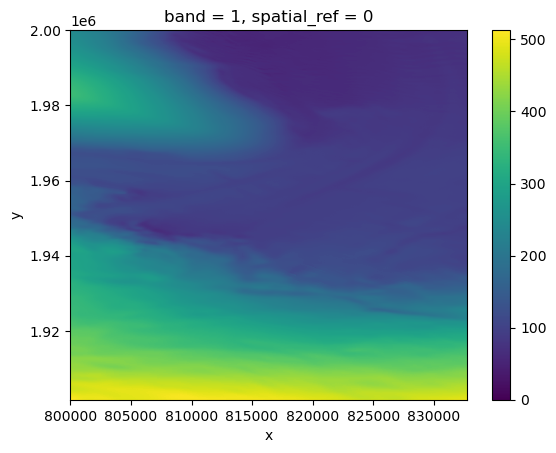

In [16]:
import rioxarray

dem = rioxarray.open_rasterio('../rema_subsets/dem_small_2_old.tif')
dem.plot()

In [2]:
from urllib.request import urlretrieve

url = "https://raw.githubusercontent.com/r-barnes/Barnes2019-DepressionHierarchy/master/test_cases/kerry_test3.dem"  #https://github.com/r-barnes/Barnes2019-DepressionHierarchy/tree/master/test_cases

dem_filename = "downloaded.dem"
urlretrieve(url, dem_filename)

('downloaded.dem', <http.client.HTTPMessage at 0x10c794050>)

In [17]:
!rm my_DH

rm: my_DH: No such file or directory


In [ ]:
!/Users/jkingslake/Documents/science/meltwater_routing/richdem_build_new/richdem/build/apps/rd_fill_spill_merge.exe ../rema_subsets/dem_small_2_old.tif test_3 0 --swl 0.1 

dyld[76569]: Library not loaded: @rpath/libgdal.37.dylib
  Referenced from: <48607566-EB44-365B-8B45-C27B191E10DE> /Users/jkingslake/Documents/science/meltwater_routing/richdem_build_new/richdem/build/apps/rd_fill_spill_merge.exe
  Reason: tried: '/Users/jkingslake/miniconda3/envs/richdem/lib/libgdal.37.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/jkingslake/miniconda3/envs/richdem/lib/libgdal.37.dylib' (no such file), '/Users/jkingslake/Documents/science/meltwater_routing/richdem_build_new/richdem/build/libgdal.37.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/jkingslake/Documents/science/meltwater_routing/richdem_build_new/richdem/build/libgdal.37.dylib' (no such file), '/Users/jkingslake/miniconda3/envs/richdem/lib/libgdal.37.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/jkingslake/miniconda3/envs/richdem/lib/libgdal.37.dylib' (no such file), '/Users/jkingslake/Documents/science/meltwater_routing/richdem_build_new/richde

In [1]:
!echo $CONDA_DEFAULT_ENV

richdem


In [2]:
import rioxarray

dem = rioxarray.open_rasterio('test_3-wtd')
dem.plot()


RasterioIOError: test_3-wtd: No such file or directory

In [13]:
!/Users/jkingslake/Documents/science/meltwater_routing/richdem/build/apps/rd_fill_spill_merge.exe testing_DH.tiff test 0 --swl 0.1  --save_dh  my_DH

m Input DEM           = testing_DH.tiff
m Output prefix       = test
m Surface water level = 0.1
m Surface water file  = 
m Ocean level         = 0
p Reading topography...
ERROR 1: GetNoDataValue() should be called instead
m Data width  = 2687
m Data height = 3017
m Data cells  = 8106679
p Performing bucket fill...
p Getting depression hierarchy...
m Loading DH from my_DH
p Performing FillSpillMerge...
[================================================= ] (99% - 0.0s - 1 threads)] (48% - 0.1s - 1 threads)ERROR 6: test-wtd.tif: Dataset does not support the AddBand() method.
ERROR 6: test-hydrologic-surface-height.tif: Dataset does not support the AddBand() method.
Finished.
IO time   = 0.107253 s
Calc time = 1.24401 s


In [3]:
import rioxarray
dem = rioxarray.open_rasterio('/Users/jkingslake/Documents/science/meltwater_routing/richdem_build_new/richdem/build/downloaded.dem')

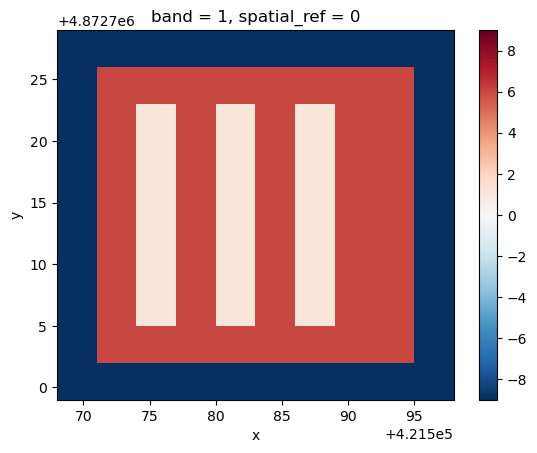

In [5]:
dem.plot()

In [12]:
import xarray as xr
input_water = xr.zeros_like(dem) +1
input_water.rio.to_raster('/Users/jkingslake/Documents/science/meltwater_routing/richdem_build_new/richdem/build/input_water.tif')

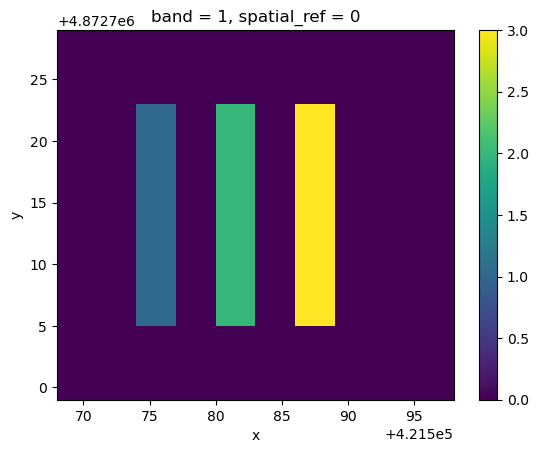

In [18]:

wtf = rioxarray.open_rasterio('/Users/jkingslake/Documents/science/meltwater_routing/richdem_build_new/richdem/build/test_with_kerrys_fork_swf-wtd.tif')
wtf.plot()